Training Crop Model using images from: D:\MindforgeAI Internship 2026 - 2026IT002- Sunaina Gaikwad\Apollo_AgriVerse\02_Datasets\Processed\Crop\Image_Dataset\train
Found 105 files belonging to 5 classes.
Found 9 files belonging to 5 classes.

Detected Crop Growth Stages (Classes): ['01_Bud_Burst', '02_Vegetative', '03_Flowering', '04_Fruit_Development', '05_Harvest']

--- Training Started ---
Epoch 1/10


C:\Users\dell\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 659ms/step - accuracy: 0.2286 - loss: 1.9815 - val_accuracy: 0.4444 - val_loss: 1.4852
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 243ms/step - accuracy: 0.4095 - loss: 1.3959 - val_accuracy: 0.4444 - val_loss: 1.4988
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 250ms/step - accuracy: 0.5143 - loss: 1.2068 - val_accuracy: 0.5556 - val_loss: 1.1963
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step - accuracy: 0.6000 - loss: 0.9819 - val_accuracy: 0.6667 - val_loss: 1.0763
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 255ms/step - accuracy: 0.6667 - loss: 0.9247 - val_accuracy: 0.4444 - val_loss: 1.1927
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 255ms/step - accuracy: 0.7333 - loss: 0.7957 - val_accuracy: 0.4444 - val_loss: 1.2513
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 258ms/step - accuracy: 0.6857 - loss: 0.7918 - val_accuracy: 0.4444 - val_loss: 1.2759
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 269ms/step - accuracy: 0.7714 - loss: 0.6840 - val_accuracy: 0.4444 - val

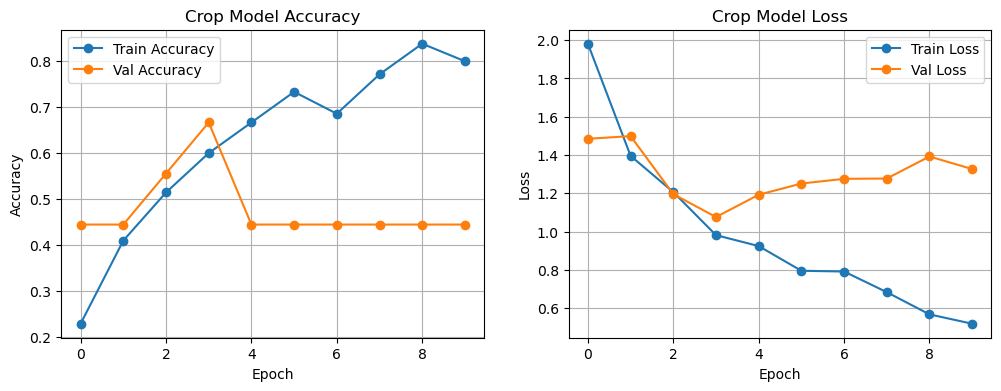

In [18]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# 1. Define base paths
base_dir = r"D:\MindforgeAI Internship 2026 - 2026IT002- Sunaina Gaikwad\Apollo_AgriVerse"
processed_crop_dir = os.path.join(base_dir, "02_Datasets", "Processed", "Crop", "Image_Dataset")

train_dir = os.path.join(processed_crop_dir, "train")
val_dir = os.path.join(processed_crop_dir, "val")

print(f"Training Crop Model using images from: {train_dir}")

# 2. Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCHS = 10
AUTOTUNE = tf.data.AUTOTUNE

# 3. Load Datasets
train_dataset = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_dataset = image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.class_names
print("\nDetected Crop Growth Stages (Classes):", class_names)

# Optimize performance
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# 4. Build Model safely without wrapper layer bugs
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train the Model
print("\n--- Training Started ---")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

# 6. Save Model Artifact
models_output_dir = os.path.join(base_dir, "06_ML", "models")
os.makedirs(models_output_dir, exist_ok=True)
model_save_path = os.path.join(models_output_dir, "grape_crop_stage_model.keras")
model.save(model_save_path)
print(f"\nModel successfully trained and saved at: {model_save_path}")

# 7. Plot Graphs
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Crop Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Crop Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()